<a href="https://colab.research.google.com/github/jaydenhurt1215-dotcom/CS4410-HW/blob/main/JHurt_Hw_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S1: Load Iris dataset

In [9]:
from sklearn.datasets import load_iris
iris = load_iris()
x = iris.data
y = iris.target

In [10]:
print (iris.DESCR)
print (x.shape)
print (y.shape)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

S2: Cross-Validation/Hyperparameter

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x, y, cv=10)
    k_scores.append(scores.mean())

In [12]:
best_score = max(k_scores)
best_k = k_scores.index(best_score) + 1

print("Best K:", best_k)
print("Top Score:", best_score)

Best K: 13
Top Score: 0.9800000000000001


S3: Graphs

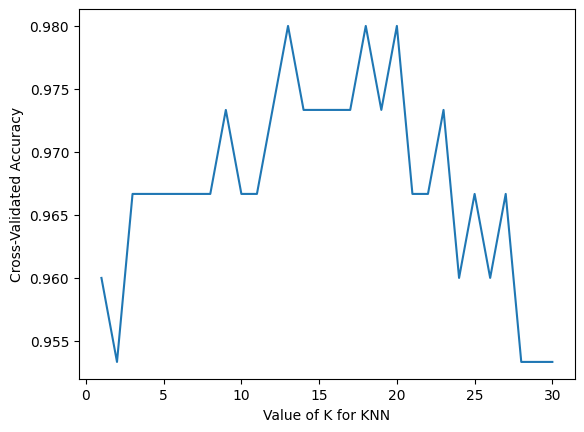

In [13]:
import matplotlib.pyplot as plt
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

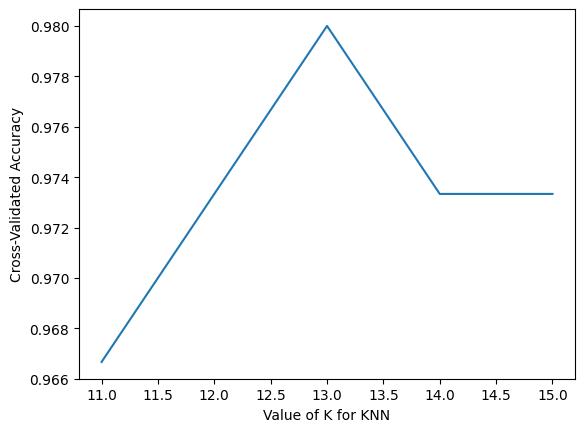

In [14]:
zoom_k = range(11, 16)
zoom_scores = [k_scores[k - 1] for k in zoom_k]

plt.plot(zoom_k, zoom_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

S4: GridSearch

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=10)
grid.fit(x, y)

print("Best K:", grid.best_params_['n_neighbors'])
print("Top Score:", grid.best_score_)


Best K: 13
Top Score: 0.9800000000000001
